<a href="https://colab.research.google.com/github/p12Ivy0/PLTMH-ELC-QLSTM/blob/main/notebooks/02_validate_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import os
import sys

REPO_URL = "https://github.com/p12Ivy0/PLTMH-ELC-QLSTM"
PROJECT_DIR = Path("/content/PLTMH-ELC-QLSTM")

# Clone hanya jika repository belum tersedia
if not PROJECT_DIR.exists():
    %cd /content
    !git clone {REPO_URL}

# Masuk ke repository
%cd /content/PLTMH-ELC-QLSTM

# Tambahkan root project ke Python path
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("\nProject directory:")
!pwd

/content
Cloning into 'PLTMH-ELC-QLSTM'...
remote: Enumerating objects: 213, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 213 (delta 28), reused 25 (delta 15), pack-reused 165 (from 1)
Receiving objects: 100% (213/213), 285.74 KiB | 5.71 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/PLTMH-ELC-QLSTM

Project directory:
/content/PLTMH-ELC-QLSTM


In [2]:
print("=== GIT STATUS ===")
!git status

print("\n=== REMOTE ===")
!git remote -v

print("\n=== BRANCH ===")
!git branch --show-current

=== GIT STATUS ===
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

=== REMOTE ===
origin	https://github.com/p12Ivy0/PLTMH-ELC-QLSTM (fetch)
origin	https://github.com/p12Ivy0/PLTMH-ELC-QLSTM (push)

=== BRANCH ===
main


In [5]:
!ls -la src/plant/synchronous_generator.py
!ls -la tests/test_generator.py
!cat src/plant/synchronous_generator.py

-rw-r--r-- 1 root root 1 Sep  5 08:38 src/plant/synchronous_generator.py
-rw-r--r-- 1 root root 1 Sep  5 08:38 tests/test_generator.py



In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.1.3
Pandas: 2.2.3


In [7]:
%%writefile /content/PLTMH-ELC-QLSTM/src/plant/synchronous_generator.py

from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp


@dataclass(frozen=True)
class GeneratorParams:
    """
    Parameter reduced-order synchronous generator
    untuk studi dinamika frekuensi PLTMH terisolasi.

    Nilai parameter pada tahap awal merupakan parameter
    simulasi dan harus divalidasi terhadap spesifikasi
    generator/literatur yang dipilih untuk tesis.
    """

    # Rating sistem
    rated_power_kw: float = 100.0
    nominal_frequency_hz: float = 50.0

    # Konfigurasi generator
    poles: int = 4

    # Parameter elektromekanik
    inertia_constant_s: float = 2.50
    damping_pu: float = 2.0


def electrical_base_speed_rad_s(
    params: GeneratorParams
) -> float:
    """
    Kecepatan sudut elektrik basis:

        omega_b = 2*pi*f0
    """
    return (
        2.0
        * np.pi
        * params.nominal_frequency_hz
    )


def synchronous_speed_rpm(
    params: GeneratorParams
) -> float:
    """
    Kecepatan sinkron mekanik:

        ns = 120*f0/p
    """
    return (
        120.0
        * params.nominal_frequency_hz
        / params.poles
    )


def frequency_hz(
    omega_pu,
    params: GeneratorParams
):
    """
    Konversi kecepatan rotor per-unit ke frekuensi:

        f = f0 * omega_pu
    """
    return (
        params.nominal_frequency_hz
        * np.asarray(omega_pu)
    )


def rotor_speed_rpm(
    omega_pu,
    params: GeneratorParams
):
    """
    Kecepatan mekanik rotor dalam rpm.
    """
    return (
        synchronous_speed_rpm(params)
        * np.asarray(omega_pu)
    )


def constant_profile(
    value: float
) -> Callable[[float], float]:
    """
    Membentuk profil daya konstan.
    """
    return lambda t: float(value)


def step_profile(
    before: float,
    after: float,
    t_step: float
) -> Callable[[float], float]:
    """
    Membentuk profil perubahan step.
    """

    def profile(t: float) -> float:

        if t < t_step:
            return float(before)

        return float(after)

    return profile


def generator_rhs(
    t: float,
    x: np.ndarray,
    params: GeneratorParams,
    pm_profile: Callable[[float], float],
    pe_profile: Callable[[float], float],
) -> np.ndarray:
    """
    Reduced-order electromechanical model.

    States:
        x[0] = omega_pu
        x[1] = delta_rad

    Swing equation:

        domega/dt =
        [Pm - Pe - D(omega - 1)] / (2H)

    Rotor angle relative to synchronous reference:

        ddelta/dt =
        omega_b * (omega - 1)
    """

    omega_pu = x[0]

    pm_pu = float(
        pm_profile(t)
    )

    pe_pu = float(
        pe_profile(t)
    )

    domega_dt = (
        pm_pu
        - pe_pu
        - params.damping_pu
        * (omega_pu - 1.0)
    ) / (
        2.0
        * params.inertia_constant_s
    )

    ddelta_dt = (
        electrical_base_speed_rad_s(params)
        * (omega_pu - 1.0)
    )

    return np.array([
        domega_dt,
        ddelta_dt
    ])


def simulate_generator(
    params: GeneratorParams,
    pm_profile: Callable[[float], float],
    pe_profile: Callable[[float], float],
    t_end_s: float = 10.0,
    dt_s: float = 0.01,
    initial_omega_pu: float = 1.0,
    initial_delta_rad: float = 0.0,
) -> pd.DataFrame:
    """
    Simulasi reduced-order synchronous generator.
    """

    x0 = np.array([
        initial_omega_pu,
        initial_delta_rad
    ])

    t_eval = np.arange(
        0.0,
        t_end_s + 0.5 * dt_s,
        dt_s
    )

    solution = solve_ivp(
        fun=lambda t, x: generator_rhs(
            t,
            x,
            params,
            pm_profile,
            pe_profile,
        ),
        t_span=(
            0.0,
            t_end_s
        ),
        y0=x0,
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
        max_step=dt_s,
    )

    if not solution.success:
        raise RuntimeError(
            solution.message
        )

    t = solution.t
    omega_pu = solution.y[0]
    delta_rad = solution.y[1]

    pm_pu = np.array([
        pm_profile(time)
        for time in t
    ])

    pe_pu = np.array([
        pe_profile(time)
        for time in t
    ])

    f_hz = frequency_hz(
        omega_pu,
        params
    )

    speed_rpm = rotor_speed_rpm(
        omega_pu,
        params
    )

    delta_f_hz = (
        f_hz
        - params.nominal_frequency_hz
    )

    power_mismatch_pu = (
        pm_pu
        - pe_pu
    )

    power_mismatch_kw = (
        power_mismatch_pu
        * params.rated_power_kw
    )

    rocof_hz_s = np.gradient(
        f_hz,
        t
    )

    return pd.DataFrame({
        "time_s": t,
        "pm_pu": pm_pu,
        "pe_pu": pe_pu,
        "power_mismatch_pu": power_mismatch_pu,
        "power_mismatch_kw": power_mismatch_kw,
        "omega_pu": omega_pu,
        "frequency_hz": f_hz,
        "delta_f_hz": delta_f_hz,
        "rotor_speed_rpm": speed_rpm,
        "delta_rad": delta_rad,
        "delta_deg": np.rad2deg(delta_rad),
        "rocof_hz_s": rocof_hz_s,
    })

Overwriting /content/PLTMH-ELC-QLSTM/src/plant/synchronous_generator.py


In [8]:
!wc -l src/plant/synchronous_generator.py
!head -n 20 src/plant/synchronous_generator.py

281 src/plant/synchronous_generator.py

from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp


@dataclass(frozen=True)
class GeneratorParams:
    """
    Parameter reduced-order synchronous generator
    untuk studi dinamika frekuensi PLTMH terisolasi.

    Nilai parameter pada tahap awal merupakan parameter
    simulasi dan harus divalidasi terhadap spesifikasi
    generator/literatur yang dipilih untuk tesis.
    """



In [9]:
from pathlib import Path

init_file = Path(
    "/content/PLTMH-ELC-QLSTM/src/plant/__init__.py"
)

current_text = init_file.read_text()

generator_import = """

from .synchronous_generator import (
    GeneratorParams,
    electrical_base_speed_rad_s,
    synchronous_speed_rpm,
    frequency_hz,
    rotor_speed_rpm,
    generator_rhs,
    simulate_generator,
)
"""

if "from .synchronous_generator import" not in current_text:
    init_file.write_text(
        current_text + generator_import
    )
    print("Generator exports ditambahkan.")
else:
    print("Generator exports sudah tersedia.")

Generator exports ditambahkan.


In [10]:
!cat src/plant/__init__.py


from .microhydro_plant import (
    PlantParams,
    hydraulic_power_w,
    mechanical_power_w,
    nominal_flow_m3_s,
    constant_profile,
    step_profile,
    plant_rhs,
    simulate_plant,
)


from .synchronous_generator import (
    GeneratorParams,
    electrical_base_speed_rad_s,
    synchronous_speed_rpm,
    frequency_hz,
    rotor_speed_rpm,
    generator_rhs,
    simulate_generator,
)


In [15]:
from src.plant import (
    GeneratorParams,
    electrical_base_speed_rad_s,
    synchronous_speed_rpm,
    frequency_hz,
    rotor_speed_rpm,
    simulate_generator,
)

print("PASS: synchronous generator berhasil di-import.")

print("=== GENERATOR PARAMETERS ===")

print(
    f"Rated power       : "
    f"{gen_params.rated_power_kw:.2f} kW"
)

print(
    f"Nominal frequency : "
    f"{gen_params.nominal_frequency_hz:.2f} Hz"
)

print(
    f"Number of poles   : "
    f"{gen_params.poles}"
)

print(
    f"Inertia H         : "
    f"{gen_params.inertia_constant_s:.3f} s"
)

print(
    f"Damping D         : "
    f"{gen_params.damping_pu:.3f}"
)

PASS: synchronous generator berhasil di-import.
=== GENERATOR PARAMETERS ===
Rated power       : 100.00 kW
Nominal frequency : 50.00 Hz
Number of poles   : 4
Inertia H         : 2.500 s
Damping D         : 2.000


In [16]:
gen_params = GeneratorParams()

print(gen_params)

print("=== GENERATOR PARAMETERS ===")

print(
    f"Rated power       : "
    f"{gen_params.rated_power_kw:.2f} kW"
)

print(
    f"Nominal frequency : "
    f"{gen_params.nominal_frequency_hz:.2f} Hz"
)

print(
    f"Number of poles   : "
    f"{gen_params.poles}"
)

print(
    f"Inertia H         : "
    f"{gen_params.inertia_constant_s:.3f} s"
)

print(
    f"Damping D         : "
    f"{gen_params.damping_pu:.3f}"
)

GeneratorParams(rated_power_kw=100.0, nominal_frequency_hz=50.0, poles=4, inertia_constant_s=2.5, damping_pu=2.0)
=== GENERATOR PARAMETERS ===
Rated power       : 100.00 kW
Nominal frequency : 50.00 Hz
Number of poles   : 4
Inertia H         : 2.500 s
Damping D         : 2.000


In [18]:
omega_base = electrical_base_speed_rad_s(
    gen_params
)

n_sync = synchronous_speed_rpm(
    gen_params
)

print(
    f"Electrical base angular speed : "
    f"{omega_base:.4f} rad/s"
)

print(
    f"Synchronous mechanical speed  : "
    f"{n_sync:.2f} rpm"
)

assert np.isclose(
    n_sync,
    1500.0
)

print(
    "PASS: synchronous speed calculation valid."
)

Electrical base angular speed : 314.1593 rad/s
Synchronous mechanical speed  : 1500.00 rpm
PASS: synchronous speed calculation valid.


In [19]:
pm_profile = lambda t: 0.80
pe_profile = lambda t: 0.80

df_gen_balanced = simulate_generator(
    params=gen_params,
    pm_profile=pm_profile,
    pe_profile=pe_profile,
    t_end_s=10.0,
    dt_s=0.01,
    initial_omega_pu=1.0,
    initial_delta_rad=0.0,
)

df_gen_balanced.head()

,time_s,pm_pu,pe_pu,power_mismatch_pu,power_mismatch_kw,omega_pu,frequency_hz,delta_f_hz,rotor_speed_rpm,delta_rad,delta_deg,rocof_hz_s
0,0.00,0.8,0.8,0.0,0.0,1.0,50.0,0.0,1500.0,0.0,0.0,0.0
1,0.01,0.8,0.8,0.0,0.0,1.0,50.0,0.0,1500.0,0.0,0.0,0.0
2,0.02,0.8,0.8,0.0,0.0,1.0,50.0,0.0,1500.0,0.0,0.0,0.0
3,0.03,0.8,0.8,0.0,0.0,1.0,50.0,0.0,1500.0,0.0,0.0,0.0
4,0.04,0.8,0.8,0.0,0.0,1.0,50.0,0.0,1500.0,0.0,0.0,0.0


In [21]:
print(
    "Minimum frequency:",
    df_gen_balanced["frequency_hz"].min()
)

print(
    "Maximum frequency:",
    df_gen_balanced["frequency_hz"].max()
)

print(
    "Final frequency:",
    df_gen_balanced["frequency_hz"].iloc[-1]
)

max_error = np.max(
    np.abs(
        df_gen_balanced["frequency_hz"]
        - 50.0
    )
)

assert max_error < 1e-6

print(
    "PASS: generator equilibrium valid."
)

Minimum frequency: 50.0
Maximum frequency: 50.0
Final frequency: 50.0
PASS: generator equilibrium valid.


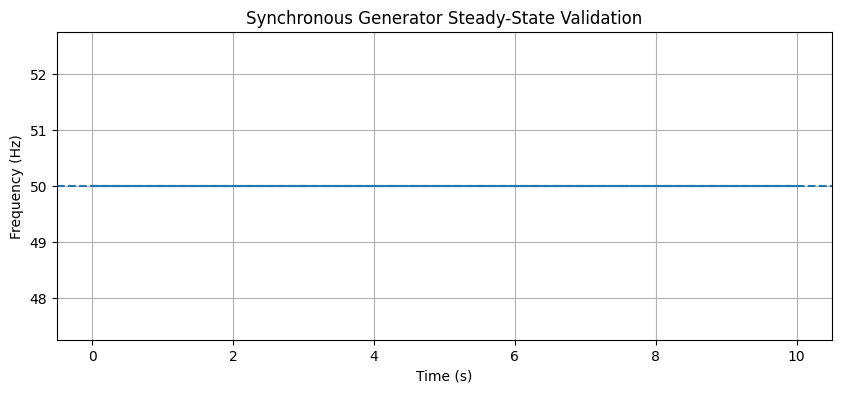

In [22]:
plt.figure(figsize=(10, 4))

plt.plot(
    df_gen_balanced["time_s"],
    df_gen_balanced["frequency_hz"]
)

plt.axhline(
    50.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(
    "Synchronous Generator Steady-State Validation"
)
plt.grid(True)

plt.show()

In [23]:
pm_profile = lambda t: 0.80

pe_load_increase = lambda t: (
    0.80 if t < 2.0 else 0.85
)

df_gen_load_increase = simulate_generator(
    params=gen_params,
    pm_profile=pm_profile,
    pe_profile=pe_load_increase,
    t_end_s=8.0,
    dt_s=0.01,
    initial_omega_pu=1.0,
)

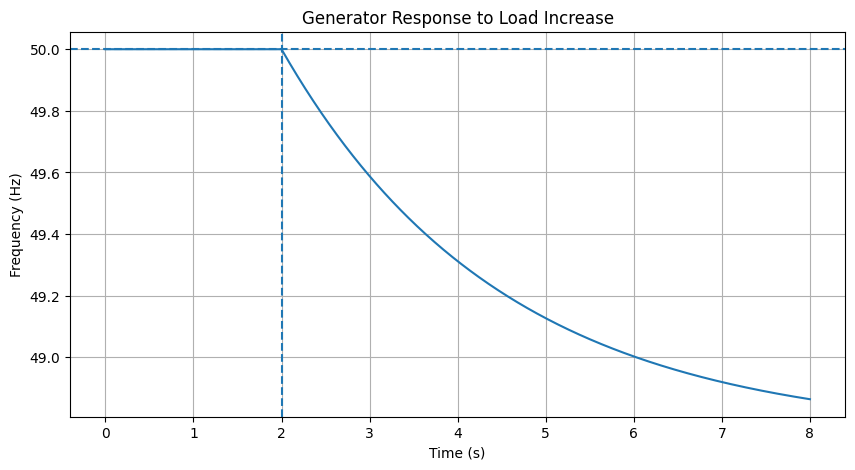

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_gen_load_increase["time_s"],
    df_gen_load_increase["frequency_hz"]
)

plt.axhline(
    50.0,
    linestyle="--"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(
    "Generator Response to Load Increase"
)
plt.grid(True)

plt.show()

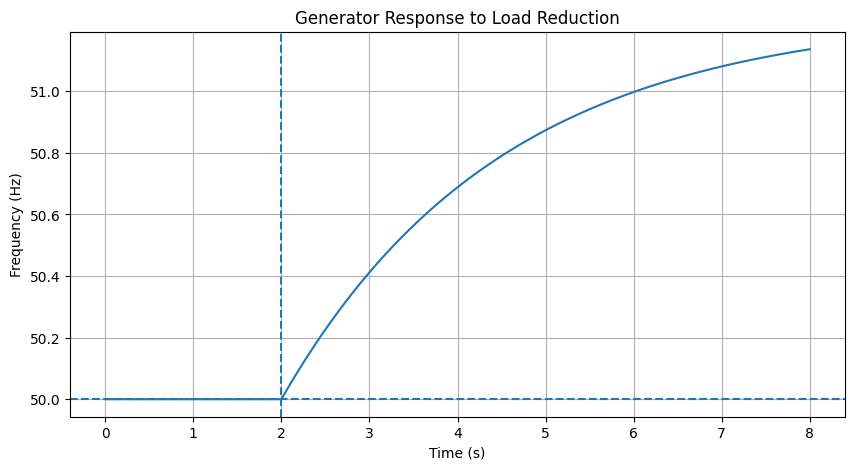

In [25]:
pe_load_drop = lambda t: (
    0.80 if t < 2.0 else 0.75
)

df_gen_load_drop = simulate_generator(
    params=gen_params,
    pm_profile=lambda t: 0.80,
    pe_profile=pe_load_drop,
    t_end_s=8.0,
    dt_s=0.01,
    initial_omega_pu=1.0,
)

plt.figure(figsize=(10, 5))

plt.plot(
    df_gen_load_drop["time_s"],
    df_gen_load_drop["frequency_hz"]
)

plt.axhline(
    50.0,
    linestyle="--"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(
    "Generator Response to Load Reduction"
)
plt.grid(True)

plt.show()

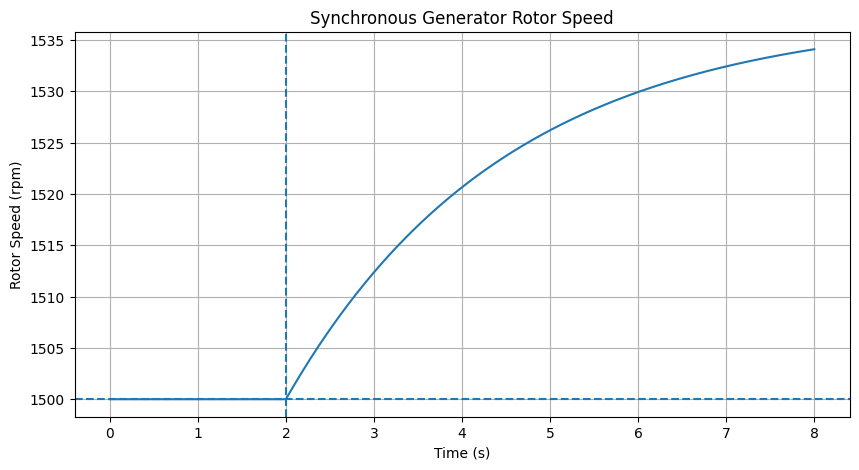

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_gen_load_drop["time_s"],
    df_gen_load_drop["rotor_speed_rpm"]
)

plt.axhline(
    synchronous_speed_rpm(gen_params),
    linestyle="--"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Rotor Speed (rpm)")
plt.title("Synchronous Generator Rotor Speed")
plt.grid(True)

plt.show()

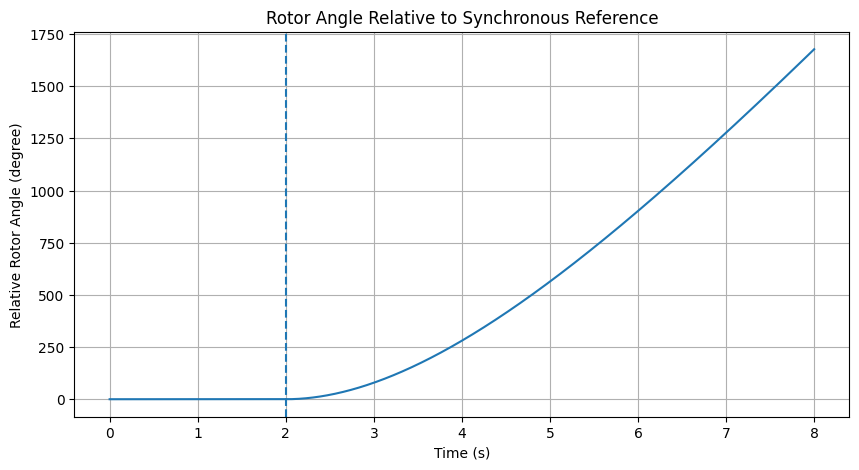

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_gen_load_drop["time_s"],
    df_gen_load_drop["delta_deg"]
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Relative Rotor Angle (degree)")
plt.title(
    "Rotor Angle Relative to Synchronous Reference"
)
plt.grid(True)

plt.show()

In [28]:
assert (
    df_gen_load_increase[
        "frequency_hz"
    ].iloc[-1]
    <
    gen_params.nominal_frequency_hz
)

assert (
    df_gen_load_drop[
        "frequency_hz"
    ].iloc[-1]
    >
    gen_params.nominal_frequency_hz
)

print(
    "PASS: generator dynamic response direction valid."
)

PASS: generator dynamic response direction valid.


In [29]:
from dataclasses import replace

H_values = [
    1.5,
    2.5,
    4.0
]

results_H = {}

for H_value in H_values:

    params_H = replace(
        gen_params,
        inertia_constant_s=H_value
    )

    result = simulate_generator(
        params=params_H,
        pm_profile=lambda t: 0.80,
        pe_profile=lambda t: (
            0.80 if t < 2.0 else 0.85
        ),
        t_end_s=5.0,
        dt_s=0.01,
    )

    results_H[H_value] = result

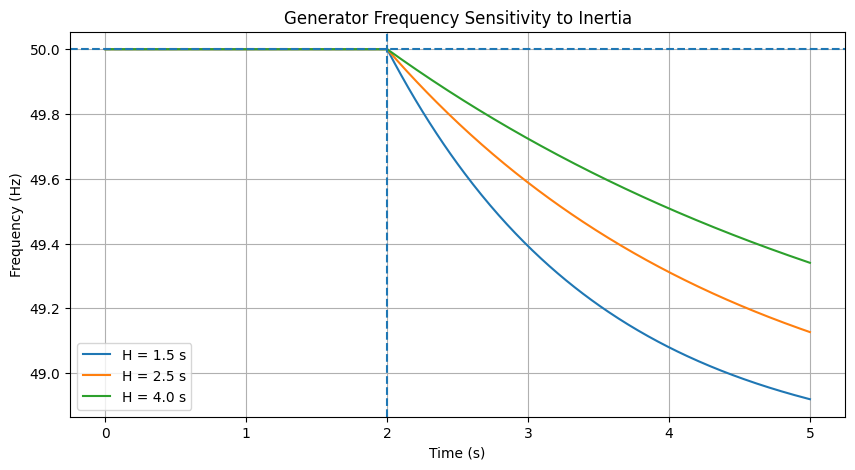

In [30]:
plt.figure(figsize=(10, 5))

for H_value, result in results_H.items():

    plt.plot(
        result["time_s"],
        result["frequency_hz"],
        label=f"H = {H_value} s"
    )

plt.axhline(
    50.0,
    linestyle="--"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(
    "Generator Frequency Sensitivity to Inertia"
)
plt.legend()
plt.grid(True)

plt.show()

In [31]:
%%writefile /content/PLTMH-ELC-QLSTM/tests/test_generator.py

import numpy as np

from src.plant import (
    GeneratorParams,
    synchronous_speed_rpm,
    simulate_generator,
)


def test_synchronous_speed():

    params = GeneratorParams(
        nominal_frequency_hz=50.0,
        poles=4
    )

    assert np.isclose(
        synchronous_speed_rpm(params),
        1500.0
    )


def test_generator_equilibrium():

    params = GeneratorParams()

    result = simulate_generator(
        params=params,
        pm_profile=lambda t: 0.80,
        pe_profile=lambda t: 0.80,
        t_end_s=3.0,
        dt_s=0.01,
    )

    max_error = np.max(
        np.abs(
            result["frequency_hz"]
            - params.nominal_frequency_hz
        )
    )

    assert max_error < 1e-6


def test_load_increase_decreases_frequency():

    params = GeneratorParams()

    result = simulate_generator(
        params=params,
        pm_profile=lambda t: 0.80,
        pe_profile=lambda t: (
            0.80 if t < 1.0 else 0.85
        ),
        t_end_s=4.0,
        dt_s=0.01,
    )

    assert (
        result["frequency_hz"].iloc[-1]
        <
        params.nominal_frequency_hz
    )


def test_load_drop_increases_frequency():

    params = GeneratorParams()

    result = simulate_generator(
        params=params,
        pm_profile=lambda t: 0.80,
        pe_profile=lambda t: (
            0.80 if t < 1.0 else 0.75
        ),
        t_end_s=4.0,
        dt_s=0.01,
    )

    assert (
        result["frequency_hz"].iloc[-1]
        >
        params.nominal_frequency_hz
    )


def test_higher_inertia_reduces_rocof():

    params_low = GeneratorParams(
        inertia_constant_s=1.5
    )

    params_high = GeneratorParams(
        inertia_constant_s=4.0
    )

    pe_profile = lambda t: (
        0.80 if t < 1.0 else 0.85
    )

    result_low = simulate_generator(
        params=params_low,
        pm_profile=lambda t: 0.80,
        pe_profile=pe_profile,
        t_end_s=2.0,
        dt_s=0.01,
    )

    result_high = simulate_generator(
        params=params_high,
        pm_profile=lambda t: 0.80,
        pe_profile=pe_profile,
        t_end_s=2.0,
        dt_s=0.01,
    )

    mask_low = (
        result_low["time_s"] >= 1.0
    )

    mask_high = (
        result_high["time_s"] >= 1.0
    )

    rocof_low = np.max(
        np.abs(
            result_low.loc[
                mask_low,
                "rocof_hz_s"
            ]
        )
    )

    rocof_high = np.max(
        np.abs(
            result_high.loc[
                mask_high,
                "rocof_hz_s"
            ]
        )
    )

    assert rocof_high < rocof_low

Overwriting /content/PLTMH-ELC-QLSTM/tests/test_generator.py


In [32]:
%cd /content/PLTMH-ELC-QLSTM

!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q tests/test_generator.py

/content/PLTMH-ELC-QLSTM
.....                                                                    [100%]
5 passed in 1.24s


In [33]:
!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q

.........                                                                [100%]
9 passed in 2.61s


In [34]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   src/plant/__init__.py
	modified:   src/plant/synchronous_generator.py
	modified:   tests/test_generator.py

no changes added to commit (use "git add" and/or "git commit -a")


In [35]:
!git add src/plant/__init__.py
!git add src/plant/synchronous_generator.py
!git add tests/test_generator.py

!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   src/plant/__init__.py
	modified:   src/plant/synchronous_generator.py
	modified:   tests/test_generator.py



In [36]:
!git config --global user.name "p12Ivy0"
!git config --global user.email "ypriyogunos@gmail.com"
!git commit -m "Add reduced-order synchronous generator model and tests"

[main 204ab76] Add reduced-order synchronous generator model and tests
 3 files changed, 434 insertions(+)


In [37]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [38]:
from google.colab import userdata
import subprocess

github_token = userdata.get("GITHUB_TOKEN")

result = subprocess.run(
    [
        "gh",
        "auth",
        "login",
        "--hostname",
        "github.com",
        "--with-token",
    ],
    input=github_token,
    text=True,
    capture_output=True,
)

if result.returncode == 0:
    print("PASS: autentikasi GitHub berhasil.")
else:
    print("Autentikasi gagal:")
    print(result.stderr)

PASS: autentikasi GitHub berhasil.


In [39]:
!gh auth setup-git

In [40]:
!gh auth status

github.com
  ✓ Logged in to github.com account p12Ivy0 (/root/.config/gh/hosts.yml)
  - Active account: true
  - Git operations protocol: https
  - Token: github_pat_**********************************************************************************


In [41]:
%cd /content/PLTMH-ELC-QLSTM
!git push origin main

/content/PLTMH-ELC-QLSTM
Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 2.81 KiB | 2.81 MiB/s, done.
Total 8 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/p12Ivy0/PLTMH-ELC-QLSTM
   9c7e638..204ab76  main -> main


In [42]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
